# Ridge Regression 

In [ ]:

from google.colab import drive
drive.mount('/content/drive', force_remount=False)

from pathlib import Path
PROJECT = Path('/content/drive/MyDrive/MSC THESIS')         # adjust if needed
DATA_DIR = PROJECT / 'ml_dataset' / 'data' / 'model_ready' / 'movie_success_v6'
RUN_DIR = DATA_DIR / 'colab_runs_v2'
RUN_DIR.mkdir(parents=True, exist_ok=True)


for f in ['movie_features_v6.csv',
          'movie_features_v6_synthetic.csv',
          'scene_movie_metadata_v6.csv',
          'scene_movie_metadata_v6_synthetic.csv']:
    assert (DATA_DIR / f).exists(), f'Missing: {f}'

print('Data dir:', DATA_DIR)
print('Run dir: ', RUN_DIR)

Mounted at /content/drive
Data dir: /content/drive/MyDrive/MSC THESIS/ml_dataset/data/model_ready/movie_success_v6
Run dir:  /content/drive/MyDrive/MSC THESIS/ml_dataset/data/model_ready/movie_success_v6/colab_runs_v2


In [ ]:
import warnings; warnings.filterwarnings('ignore')
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    LeaveOneOut, KFold, StratifiedKFold, GridSearchCV, cross_val_predict,
)
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
)
from scipy.stats import spearmanr, pearsonr

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 180)
plt.rcParams['figure.dpi'] = 100
np.random.seed(42)
print('Imports OK')

Imports OK


# Data loading

In [ ]:

real_mov  = pd.read_csv(DATA_DIR / 'movie_features_v6.csv')
syn_mov   = pd.read_csv(DATA_DIR / 'movie_features_v6_synthetic.csv')
real_meta = pd.read_csv(DATA_DIR / 'scene_movie_metadata_v6.csv')
syn_meta  = pd.read_csv(DATA_DIR / 'scene_movie_metadata_v6_synthetic.csv')


LEAKAGE_AND_OLD_TARGETS = [
    'budget_usd', 'revenue_usd', 'roi_percent', 'success_class',
    'imdb_rating', 'wom_multiplier', 'wom_multiplier_log',
]
real_mov = real_mov.drop(columns=LEAKAGE_AND_OLD_TARGETS, errors='ignore')
syn_mov  = syn_mov.drop(columns=LEAKAGE_AND_OLD_TARGETS, errors='ignore')


META_KEEP = [
    'movie_id',
    # Scene properties
    'targeted_emotion', 'clip_duration_s',
    'cut_count', 'brightness', 'motion_intensity', 'audio_loudness',
    'silence_ratio', 'music_presence', 'dialogue_density',
    'face_screen_time_ratio', 'lead_screen_time_ratio',
    # Movie metadata
    'release_year', 'genre_primary', 'genre_secondary',
    'country_of_origin', 'budget_categorical',
    # Targets (kept to extract y; not used as features)
    'imdb_rating', 'wom_multiplier', 'wom_multiplier_log',
]
real_meta_sub = real_meta[[c for c in META_KEEP if c in real_meta.columns]]
syn_meta_sub  = syn_meta[[c for c in META_KEEP if c in syn_meta.columns]]

real_mov = real_mov.merge(real_meta_sub, on='movie_id', how='left')
real_mov['is_synthetic'] = 0
syn_mov = syn_mov.merge(syn_meta_sub, on='movie_id', how='left')
syn_mov['is_synthetic'] = 1

df_all = pd.concat([real_mov, syn_mov], ignore_index=True)
print(f'Real:      {len(real_mov)} movies')
print(f'Synthetic: {len(syn_mov)} movies')
print(f'Combined:  {len(df_all)} movies × {len(df_all.columns)} columns (pre-encoding)')
print()
print('Target distributions (pre-encoding):')
display(df_all[['is_synthetic', 'imdb_rating', 'wom_multiplier_log']]
        .groupby('is_synthetic').describe().round(2))

Real:      10 movies
Synthetic: 40 movies
Combined:  50 movies × 343 columns (pre-encoding)

Target distributions (pre-encoding):


imdb_rating                                        wom_multiplier_log                                          
                   count  mean   std  min  25%   50%   75%  max              count  mean   std   min   25%   50%   75%   max
is_synthetic                                                                                                                
0                   10.0  7.41  0.73  6.5  6.8  7.45  8.02  8.5               10.0  1.77  0.64  0.75  1.28  1.88  2.21  2.73
1                   40.0  7.48  0.55  6.5  7.0  7.50  7.82  8.4               40.0  1.70  0.54  0.34  1.28  1.86  2.04  2.91

# Feature preparation

In [ ]:

DROP = {
    'movie_id', 'condition', 'n_participants',
    # Targets (cannot be features)
    'imdb_rating', 'wom_multiplier', 'wom_multiplier_log',
    # Control flag (not a feature)
    'is_synthetic',
}

df_feat = df_all.copy()

ORD_MAP = {'low': 1, 'moderate': 2, 'high': 3}
ORD_COLS = ['cut_count', 'brightness', 'motion_intensity', 'audio_loudness',
            'silence_ratio', 'music_presence', 'dialogue_density',
            'face_screen_time_ratio', 'lead_screen_time_ratio',
            'budget_categorical']
for c in ORD_COLS:
    if c in df_feat.columns:
        df_feat[c] = df_feat[c].map(ORD_MAP)

OH_COLS = ['targeted_emotion', 'genre_primary', 'genre_secondary', 'country_of_origin']
OH_COLS = [c for c in OH_COLS if c in df_feat.columns]
df_feat = pd.get_dummies(df_feat, columns=OH_COLS, prefix_sep='_',
                         dummy_na=False, dtype=int)


feature_cols = [c for c in df_feat.columns if c not in DROP]
X_all = df_feat[feature_cols].apply(pd.to_numeric, errors='coerce')
y_imdb_all = df_feat['imdb_rating'].astype(float)
y_wom_all  = df_feat['wom_multiplier_log'].astype(float)
groups_all = df_feat['movie_id'].values if 'movie_id' in df_feat.columns else np.arange(len(df_feat))
synth_mask_all = df_feat['is_synthetic'].values.astype(bool)


all_nan_cols = X_all.columns[X_all.isna().all()].tolist()
if all_nan_cols:
    print(f'Dropping {len(all_nan_cols)} all-NaN columns')
    X_all = X_all.drop(columns=all_nan_cols)


zero_var_cols = X_all.columns[X_all.std() == 0].tolist()
if zero_var_cols:
    print(f'Dropping {len(zero_var_cols)} zero-variance columns')
    X_all = X_all.drop(columns=zero_var_cols)

feature_cols = list(X_all.columns)

phys_cols = [c for c in feature_cols if c.endswith('__mean') or c.endswith('__std')]
ord_in_X  = [c for c in feature_cols if c in ORD_COLS]
oh_in_X   = [c for c in feature_cols
             if any(c.startswith(p + '_') for p in
                    ['targeted_emotion', 'genre_primary', 'genre_secondary',
                     'country_of_origin'])]
other_cols = [c for c in feature_cols
              if c not in phys_cols + ord_in_X + oh_in_X]

print(f'\nFinal feature matrix: {X_all.shape}')
print(f'  Physiological (mean/std):  {len(phys_cols):>4d}')
print(f'  Scene/movie ordinal:       {len(ord_in_X):>4d}  ({ord_in_X})')
print(f'  Scene/movie one-hot:       {len(oh_in_X):>4d}')
print(f'  Other numeric (year, dur): {len(other_cols):>4d}  ({other_cols})')
print(f'  TOTAL features:            {len(feature_cols):>4d}')


Final feature matrix: (50, 360)
  Physiological (mean/std):   320
  Scene/movie ordinal:         10  (['cut_count', 'brightness', 'motion_intensity', 'audio_loudness', 'silence_ratio', 'music_presence', 'dialogue_density', 'face_screen_time_ratio', 'lead_screen_time_ratio', 'budget_categorical'])
  Scene/movie one-hot:         28
  Other numeric (year, dur):    2  (['clip_duration_s', 'release_year'])
  TOTAL features:             360


# Evaluation helpers

In [ ]:


def regression_metrics(y_true, y_pred):
    """Compute R², MAE, RMSE, Spearman, Pearson."""
    mask = ~(np.isnan(y_pred) | np.isnan(y_true))
    yt, yp = np.asarray(y_true)[mask], np.asarray(y_pred)[mask]
    if len(yt) < 3:
        return {'n': len(yt), 'r2': np.nan, 'mae': np.nan, 'rmse': np.nan,
                'spearman': np.nan, 'pearson': np.nan}
    return {
        'n': len(yt),
        'r2': r2_score(yt, yp),
        'mae': mean_absolute_error(yt, yp),
        'rmse': np.sqrt(mean_squared_error(yt, yp)),
        'spearman': spearmanr(yt, yp).correlation,
        'pearson': pearsonr(yt, yp)[0],
    }


def loo_predict(estimator, X, y):
    """Leave-one-out cross-validated predictions."""
    loo = LeaveOneOut()
    return cross_val_predict(estimator, X, y, cv=loo, n_jobs=-1)


def kfold_predict(estimator, X, y, n_splits=5, random_state=42):
    """K-fold CV predictions (k=5 default)."""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    return cross_val_predict(estimator, X, y, cv=kf, n_jobs=-1)


def report(metrics, title=''):
    print(f'\n──── {title} ────')
    for k, v in metrics.items():
        if k == 'n':
            print(f'  {k:>10s}: {v}')
        else:
            print(f'  {k:>10s}: {v:.3f}' if not np.isnan(v) else f'  {k:>10s}: NaN')


def plot_pred_vs_actual(y_true, y_pred, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    mask = ~(np.isnan(y_pred) | np.isnan(y_true))
    yt, yp = np.asarray(y_true)[mask], np.asarray(y_pred)[mask]
    ax.scatter(yt, yp, alpha=0.6, s=40, edgecolor='k', linewidth=0.5)
    lo, hi = min(yt.min(), yp.min()), max(yt.max(), yp.max())
    ax.plot([lo, hi], [lo, hi], 'r--', alpha=0.5, label='y = x')
    r2 = r2_score(yt, yp)
    rho = spearmanr(yt, yp).correlation
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{title}\nR² = {r2:.2f}, Spearman ρ = {rho:.2f}')
    ax.legend()
    ax.grid(alpha=0.3)
    return ax

# Real-only (LOO CV, n = 10)

In [ ]:
from sklearn.linear_model import Ridge

mask_real = ~synth_mask_all
X_real = X_all[mask_real].reset_index(drop=True)
y_imdb_real = y_imdb_all[mask_real].reset_index(drop=True)
y_wom_real = y_wom_all[mask_real].reset_index(drop=True)

def make_ridge_pipeline(alpha=1.0):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=alpha, random_state=42)),
    ])

# Baseline
pipe = make_ridge_pipeline(alpha=1.0)
y_pred = loo_predict(pipe, X_real, y_imdb_real)
metrics_real_imdb_baseline = regression_metrics(y_imdb_real, y_pred)
report(metrics_real_imdb_baseline, 'Real / IMDb / baseline')

pipe = make_ridge_pipeline(alpha=1.0)
y_pred = loo_predict(pipe, X_real, y_wom_real)
metrics_real_wom_baseline = regression_metrics(y_wom_real, y_pred)
report(metrics_real_wom_baseline, 'Real / WOM-log / baseline')


──── Real / IMDb / baseline ────
           n: 10
          r2: -0.973
         mae: 0.898
        rmse: 0.978
    spearman: -0.713
     pearson: -0.678

──── Real / WOM-log / baseline ────
           n: 10
          r2: -0.759
         mae: 0.718
        rmse: 0.802
    spearman: -0.770
     pearson: -0.760


# Tuned

In [ ]:
# Wider alpha grid in log-space.
param_grid = {'model__alpha': np.logspace(-4, 4, 30).tolist()}

search = GridSearchCV(make_ridge_pipeline(), param_grid,
                     cv=LeaveOneOut(), scoring='neg_mean_absolute_error',
                     n_jobs=-1, refit=True)
search.fit(X_real, y_imdb_real)
best_params_imdb_real = search.best_params_
y_pred_real_imdb_tuned = loo_predict(search.best_estimator_, X_real, y_imdb_real)
metrics_real_imdb_tuned = regression_metrics(y_imdb_real, y_pred_real_imdb_tuned)
print(f'\nBest IMDb params: {best_params_imdb_real}')
report(metrics_real_imdb_tuned, 'Real / IMDb / tuned')

search = GridSearchCV(make_ridge_pipeline(), param_grid,
                     cv=LeaveOneOut(), scoring='neg_mean_absolute_error',
                     n_jobs=-1, refit=True)
search.fit(X_real, y_wom_real)
best_params_wom_real = search.best_params_
y_pred_real_wom_tuned = loo_predict(search.best_estimator_, X_real, y_wom_real)
metrics_real_wom_tuned = regression_metrics(y_wom_real, y_pred_real_wom_tuned)
print(f'\nBest WOM params: {best_params_wom_real}')
report(metrics_real_wom_tuned, 'Real / WOM-log / tuned')


Best IMDb params: {'model__alpha': 10000.0}

──── Real / IMDb / tuned ────
           n: 10
          r2: -0.260
         mae: 0.685
        rmse: 0.782
    spearman: -0.970
     pearson: -0.991

Best WOM params: {'model__alpha': 10000.0}

──── Real / WOM-log / tuned ────
           n: 10
          r2: -0.254
         mae: 0.578
        rmse: 0.677
    spearman: -1.000
     pearson: -0.996


# Augmented (5-fold CV, n = 50)

In [ ]:
# Baseline
pipe = make_ridge_pipeline(alpha=1.0)
y_pred_aug_imdb = kfold_predict(pipe, X_all, y_imdb_all, n_splits=5)
metrics_aug_imdb_baseline = regression_metrics(y_imdb_all, y_pred_aug_imdb)
report(metrics_aug_imdb_baseline, 'Augmented / IMDb / baseline')

pipe = make_ridge_pipeline(alpha=1.0)
y_pred_aug_wom = kfold_predict(pipe, X_all, y_wom_all, n_splits=5)
metrics_aug_wom_baseline = regression_metrics(y_wom_all, y_pred_aug_wom)
report(metrics_aug_wom_baseline, 'Augmented / WOM-log / baseline')


──── Augmented / IMDb / baseline ────
           n: 50
          r2: 0.380
         mae: 0.354
        rmse: 0.453
    spearman: 0.632
     pearson: 0.646

──── Augmented / WOM-log / baseline ────
           n: 50
          r2: 0.051
         mae: 0.406
        rmse: 0.534
    spearman: 0.347
     pearson: 0.369


In [ ]:
# Augmented — same wider alpha grid
search = GridSearchCV(make_ridge_pipeline(), param_grid,
                     cv=KFold(n_splits=5, shuffle=True, random_state=42),
                     scoring='neg_mean_absolute_error', n_jobs=-1, refit=True)
search.fit(X_all, y_imdb_all)
best_params_imdb = search.best_params_
y_pred_aug_imdb_tuned = kfold_predict(search.best_estimator_, X_all, y_imdb_all, n_splits=5)
metrics_aug_imdb_tuned = regression_metrics(y_imdb_all, y_pred_aug_imdb_tuned)
print(f'\nBest IMDb params: {best_params_imdb}')
report(metrics_aug_imdb_tuned, 'Augmented / IMDb / tuned')

search = GridSearchCV(make_ridge_pipeline(), param_grid,
                     cv=KFold(n_splits=5, shuffle=True, random_state=42),
                     scoring='neg_mean_absolute_error', n_jobs=-1, refit=True)
search.fit(X_all, y_wom_all)
best_params_wom = search.best_params_
y_pred_aug_wom_tuned = kfold_predict(search.best_estimator_, X_all, y_wom_all, n_splits=5)
metrics_aug_wom_tuned = regression_metrics(y_wom_all, y_pred_aug_wom_tuned)
print(f'\nBest WOM params: {best_params_wom}')
report(metrics_aug_wom_tuned, 'Augmented / WOM-log / tuned')


Best IMDb params: {'model__alpha': 117.21022975334793}

──── Augmented / IMDb / tuned ────
           n: 50
          r2: 0.472
         mae: 0.317
        rmse: 0.418
    spearman: 0.668
     pearson: 0.687

Best WOM params: {'model__alpha': 417.53189365604004}

──── Augmented / WOM-log / tuned ────
           n: 50
          r2: 0.147
         mae: 0.406
        rmse: 0.507
    spearman: 0.358
     pearson: 0.385


# Visuals

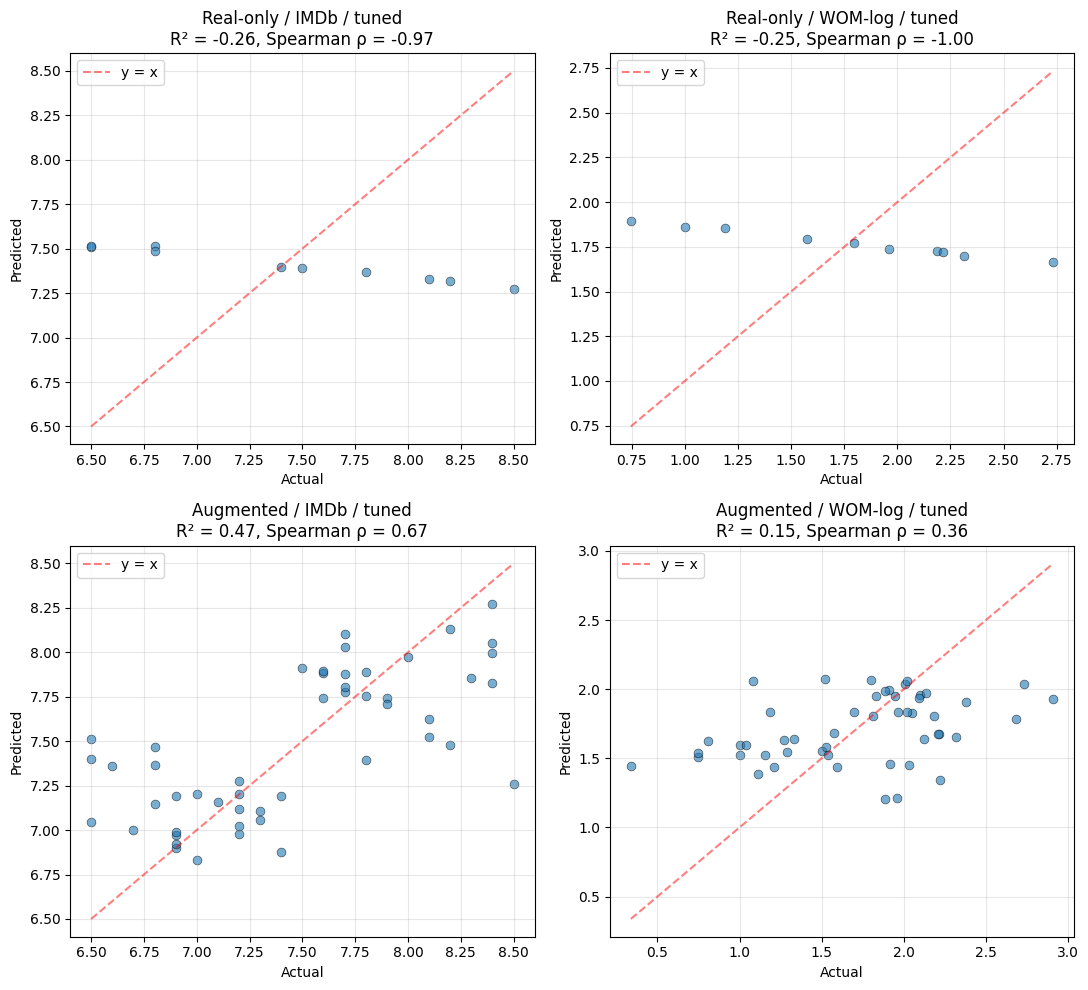

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 10))
plot_pred_vs_actual(y_imdb_real, y_pred_real_imdb_tuned,
                    'Real-only / IMDb / tuned', axes[0, 0])
plot_pred_vs_actual(y_wom_real, y_pred_real_wom_tuned,
                    'Real-only / WOM-log / tuned', axes[0, 1])
plot_pred_vs_actual(y_imdb_all, y_pred_aug_imdb_tuned,
                    'Augmented / IMDb / tuned', axes[1, 0])
plot_pred_vs_actual(y_wom_all, y_pred_aug_wom_tuned,
                    'Augmented / WOM-log / tuned', axes[1, 1])
plt.tight_layout()
plt.show()

# Coefficients, top features

Top 30 ridge coefficients:


,feature,coef,abs_coef
333,targeted_emotion_ANGER,0.0177,0.0177
256,sr_emo_bc_disgust__mean,0.0169,0.0169
268,sr_emo_disgust__mean,0.0166,0.0166
337,targeted_emotion_FEAR,-0.0161,0.0161
346,genre_primary_drama,-0.0157,0.0157
70,emp_movement_std__mean,-0.0151,0.0151
221,q_neutral_max__std,-0.0145,0.0145
352,genre_secondary_drama,0.0145,0.0145
246,sr_emo_anger__mean,0.0143,0.0143
110,movie_familiarity__mean,0.0143,0.0143


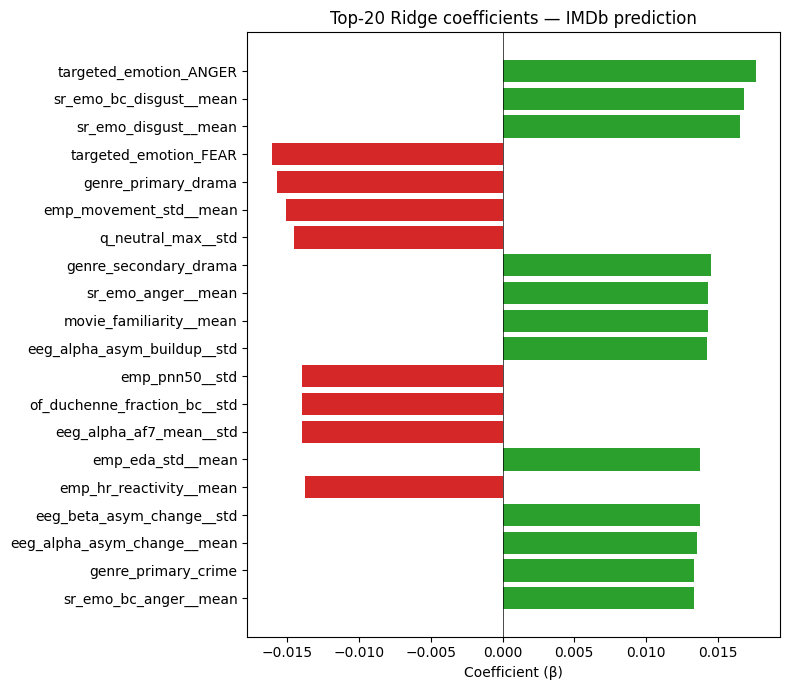

In [ ]:
final_pipe = make_ridge_pipeline(**{k.replace('model__', ''): v for k, v in best_params_imdb.items()})
final_pipe.fit(X_all, y_imdb_all)
coefs = final_pipe.named_steps['model'].coef_

coef_df = (pd.DataFrame({'feature': feature_cols, 'coef': coefs})
           .assign(abs_coef=lambda d: d.coef.abs())
           .sort_values('abs_coef', ascending=False))
print('Top 30 ridge coefficients:')
display(coef_df.head(30).round(4))

top = coef_df.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#2ca02c' if c > 0 else '#d62728' for c in top['coef']]
ax.barh(top['feature'], top['coef'], color=colors)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Coefficient (β)')
ax.set_title('Top-20 Ridge coefficients — IMDb prediction')
plt.tight_layout()
plt.show()

# Save results

In [ ]:
# Save results
out_path = RUN_DIR / 'results_ridge.json'
results_to_save = {
    'model': 'ridge',
    'feature_count': len(feature_cols),
    'best_params_imdb': best_params_imdb,
    'best_params_wom':  best_params_wom,
    'metrics_real_imdb_baseline': metrics_real_imdb_baseline,
    'metrics_real_wom_baseline':  metrics_real_wom_baseline,
    'metrics_real_imdb_tuned':    metrics_real_imdb_tuned,
    'metrics_real_wom_tuned':     metrics_real_wom_tuned,
    'metrics_aug_imdb_baseline':  metrics_aug_imdb_baseline,
    'metrics_aug_wom_baseline':   metrics_aug_wom_baseline,
    'metrics_aug_imdb_tuned':     metrics_aug_imdb_tuned,
    'metrics_aug_wom_tuned':      metrics_aug_wom_tuned,
}
with open(out_path, 'w') as f:
    json.dump(results_to_save, f, indent=2, default=str)

print(f'\nSaved → {out_path}')


Saved → /content/drive/MyDrive/MSC THESIS/ml_dataset/data/model_ready/movie_success_v6/colab_runs_v2/results_ridge.json
